In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [17]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [18]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [19]:
# Shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [20]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      X.append(context)
      ix = stoi[ch]
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [101]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join([itos[ix.item()] for ix in x]), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [102]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
          self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
      
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
      
    def parameters(self):
        return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]
        
# -----------------------------------------------------------------------------------------------
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # get parameters of all layers and stretch them into a single list
        return [p for layer in self.layers for p in layer.parameters()]

In [103]:
torch.manual_seed(42); # seed rng for reproducibility

In [104]:
n_embd = 10           # the dimensionality of the character embeddings
n_hidden = 200        # number of neurons in the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embd), Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])
 
# parameter init
with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident

parameters = model.parameters() 

print(sum(p.nelement() for p in parameters)) # no. of parameters in total

for p in parameters:
    p.requires_grad = True

12097


In [105]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # mini-batch construct
    mb_ixs = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[mb_ixs], Ytr[mb_ixs]
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits , Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr  * p.grad

    # track stats
    if(i % 10000 == 0): # print every once in a while
        print(f'{i:7d}/{max_steps:7d}:{loss:.4f}')
    lossi.append(loss.log10().item())
    # if i >= 1000:
        # break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000:3.4915
  10000/ 200000:2.2179
  20000/ 200000:2.3681
  30000/ 200000:2.1342
  40000/ 200000:2.4067
  50000/ 200000:2.2406
  60000/ 200000:1.9608
  70000/ 200000:1.9236
  80000/ 200000:2.6588
  90000/ 200000:2.0502
 100000/ 200000:2.2596
 110000/ 200000:1.6384
 120000/ 200000:2.1368
 130000/ 200000:2.2431
 140000/ 200000:2.0307
 150000/ 200000:1.9080
 160000/ 200000:1.8423
 170000/ 200000:2.3018
 180000/ 200000:2.0475
 190000/ 200000:2.1647


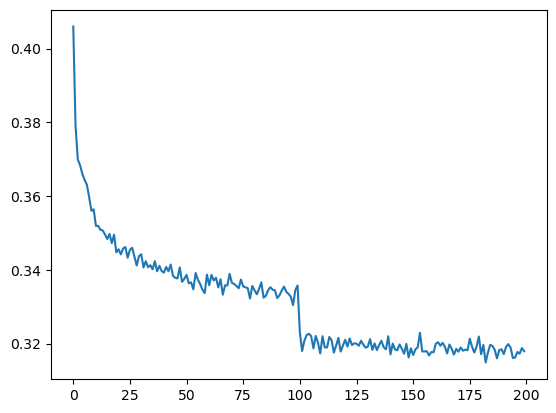

In [106]:
meanloss = torch.tensor(lossi).view(-1, 1000).mean(1, keepdim=True);
plt.plot(meanloss)

In [107]:
# Put layers into eval mode:
for layer in model.layers:
    layer.training = False

In [108]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':(Xdev, Ydev),
        'test':(Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')    

train 2.062119483947754
val 2.107567310333252


In [109]:
# sample from the model

for _ in range(20):
    out=[]
    context = [0] * block_size # initialize with all ...
    while(True):
        # forward pass the neural net
        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # track the samples and shift the context window
        out.append(itos[ix])
        context = context[1:] + [ix]
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(out)) # print the generated word

imon.
fadily.
thioumasa.
emma.
matton.
bayla.
aleigh.
kelynnie.
jazuky.
chllow.
jah.
jorrena.
joriah.
jas.
vishylaharia.
juna.
vio.
orven.
mina.
laylee.
